In [17]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [18]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [19]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [20]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

NUM_CLASSES = 3

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 3 classes: Czech, India, Japan
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
import os

DATA_DIR = "../data"

print("DATA FOLDER")
print("=" * 50)

for item in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, item)

    if os.path.isdir(path):
        print(f"[FOLDER] {item}")
    else:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"[FILE]   {item} - {size_mb:.2f} MB")

DATA FOLDER
[FOLDER] cnn_train
[FILE]   delete this.tct - 0.00 MB
[FOLDER] extracted
[FOLDER] test1
[FILE]   test1.tar.gz - 177.84 MB
[FILE]   test1_file_list.txt - 0.19 MB
[FOLDER] test2
[FILE]   test2.tar.gz - 179.96 MB
[FILE]   test2_file_list.txt - 0.19 MB
[FILE]   train_check.txt - 1.87 MB
[FILE]   train_corrupted.tar.gz - 795.76 MB
[FILE]   train_file_list.txt - 1.87 MB
[FOLDER] train_partial


In [22]:
TRAIN_LIST = os.path.join(DATA_DIR, "train_file_list.txt")

print("Training file list exists:", os.path.exists(TRAIN_LIST))

if os.path.exists(TRAIN_LIST):
    print("\nFirst 30 entries:")
    print("=" * 60)

    with open(TRAIN_LIST, "r", encoding="utf-8", errors="ignore") as f:
        for i in range(30):
            line = f.readline()

            if not line:
                break

            print(line.rstrip())

Training file list exists: True

First 30 entries:
t r a i n / 
 
 t r a i n / C z e c h / 
 
 t r a i n / C z e c h / i m a g e s / 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 0 9 8 2 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 3 3 2 3 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 1 3 5 9 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 2 8 5 0 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 2 5 5 3 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 2 4 0 4 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 1 0 4 2 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 0 0 3 1 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 1 9 1 8 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 3 4 7 8 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 3 0 0 9 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _

In [23]:
CHECK_FILE = os.path.join(DATA_DIR, "train_check.txt")

print("train_check.txt exists:", os.path.exists(CHECK_FILE))

if os.path.exists(CHECK_FILE):
    print("\nContents:")
    print("=" * 60)

    with open(CHECK_FILE, "r", encoding="utf-8", errors="ignore") as f:
        print(f.read())

train_check.txt exists: True

Contents:
t r a i n / 
 
 t r a i n / C z e c h / 
 
 t r a i n / C z e c h / i m a g e s / 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 0 9 8 2 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 3 3 2 3 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 1 3 5 9 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 2 8 5 0 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 2 5 5 3 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 2 4 0 4 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 1 0 4 2 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 0 0 3 1 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 1 9 1 8 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 3 4 7 8 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 3 0 0 9 . j p g 
 
 t r a i n / C z e c h / i m a g e s / C z e c h _ 0 0 0 7 6 

In [24]:
print("Searching for image files...")
print("=" * 60)

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_count = 0

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_count += 1

            if image_count <= 30:
                print(os.path.join(root, file))

print("\nTotal image files found:", image_count)

Searching for image files...
../data\cnn_train\Czech\Czech_000000.jpg
../data\cnn_train\Czech\Czech_000001.jpg
../data\cnn_train\Czech\Czech_000002.jpg
../data\cnn_train\Czech\Czech_000006.jpg
../data\cnn_train\Czech\Czech_000007.jpg
../data\cnn_train\Czech\Czech_000009.jpg
../data\cnn_train\Czech\Czech_000010.jpg
../data\cnn_train\Czech\Czech_000011.jpg
../data\cnn_train\Czech\Czech_000012.jpg
../data\cnn_train\Czech\Czech_000013.jpg
../data\cnn_train\Czech\Czech_000014.jpg
../data\cnn_train\Czech\Czech_000015.jpg
../data\cnn_train\Czech\Czech_000017.jpg
../data\cnn_train\Czech\Czech_000018.jpg
../data\cnn_train\Czech\Czech_000020.jpg
../data\cnn_train\Czech\Czech_000021.jpg
../data\cnn_train\Czech\Czech_000022.jpg
../data\cnn_train\Czech\Czech_000024.jpg
../data\cnn_train\Czech\Czech_000025.jpg
../data\cnn_train\Czech\Czech_000027.jpg
../data\cnn_train\Czech\Czech_000028.jpg
../data\cnn_train\Czech\Czech_000030.jpg
../data\cnn_train\Czech\Czech_000031.jpg
../data\cnn_train\Czech\Czec

In [25]:
EXTRACTED_DIR = os.path.join(DATA_DIR, "extracted")

print("Extracted dataset structure")
print("=" * 60)

for root, dirs, files in os.walk(EXTRACTED_DIR):
    level = root.replace(EXTRACTED_DIR, "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(indent + os.path.basename(root) + "/")

Extracted dataset structure
extracted/
    test1/
        Czech/
        India/
        Japan/
    test2/
        Czech/
        India/
        Japan/


In [9]:
NUM_CLASSES = 3

In [26]:
from tensorflow.keras import layers, models

NUM_CLASSES = 3

model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [28]:
SEED = 42

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

In [29]:
from pathlib import Path

DATA_DIR = next(
    (path.resolve() for path in (Path("data"), Path("../data")) if (path / "cnn_train").is_dir()),
    None
 )

if DATA_DIR is None:
    raise FileNotFoundError("Could not find data/cnn_train. Run this notebook from the project root or notebooks folder.")

TRAIN_DIR = DATA_DIR / "cnn_train"
print("Training directory:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.is_dir())

Training directory: C:\Users\dhana\Desktop\Deep-Learning-Assignment\SE4050-Deep-Learning-Assignment\data\cnn_train
Exists: True


In [30]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Classes:", train_dataset.class_names)

Found 13142 files belonging to 3 classes.
Using 10514 files for training.
Found 13142 files belonging to 3 classes.
Using 2628 files for validation.
Classes: ['Czech', 'India', 'Japan']


In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

print("Dataset pipeline ready.")

Dataset pipeline ready.


In [32]:
CLASS_NAMES = ["Czech", "India", "Japan"]

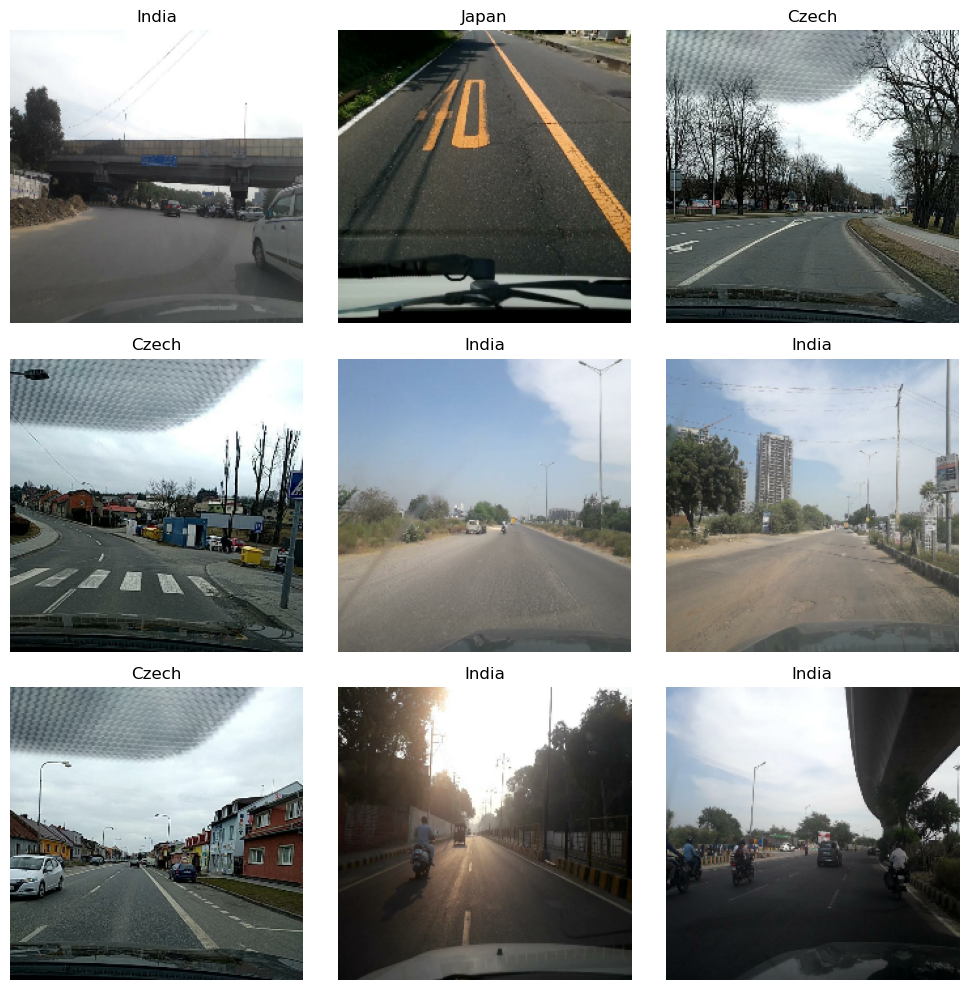

In [56]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = int(labels[i].numpy())
        plt.title(CLASS_NAMES[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

print("Callbacks ready.")

Callbacks ready.


In [36]:
NUM_CLASSES = 3

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
import tensorflow as tf

image_files = list(TRAIN_DIR.rglob("*.jpg"))
bad_images_tf = []

for file_path in image_files:
    try:
        image_bytes = tf.io.read_file(str(file_path))
        tf.io.decode_jpeg(image_bytes, channels=3)
    except Exception as error:
        bad_images_tf.append((str(file_path), str(error)))

print("Total images checked:", len(image_files))
print("TensorFlow-invalid images:", len(bad_images_tf))

for file_path, error in bad_images_tf[:20]:
    print("\nBAD IMAGE:", file_path)
    print(error[:300])

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
print("Datasets refreshed from the current files on disk.")

Total images checked: 13141
TensorFlow-invalid images: 0
Found 13141 files belonging to 3 classes.
Using 10513 files for training.
Found 13141 files belonging to 3 classes.
Using 2628 files for validation.
Datasets refreshed from the current files on disk.


In [48]:
os.makedirs("../results", exist_ok=True)

model.save("../results/custom_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [52]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.9887 - loss: 0.0418 - val_accuracy: 0.9928 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 467s 1s/step - accuracy: 0.9915 - loss: 0.0310 - val_accuracy: 0.9924 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9939 - val_loss: 0.0218 - learning_rate: 0.0010
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 720s 2s/step - accuracy: 0.9974 - loss: 0.0061 - val_accuracy: 0.9966 - val_loss: 0.0095 - learning_rate: 2.0000e-04
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step - accuracy: 0.9983 - loss: 0.0048 - val_accuracy: 0.9966 - val_loss: 0.0090 - learning_rate: 2.0000e-04
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9973 - val_loss: 0.0101 - learning_rate: 2.0000e-04
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.998

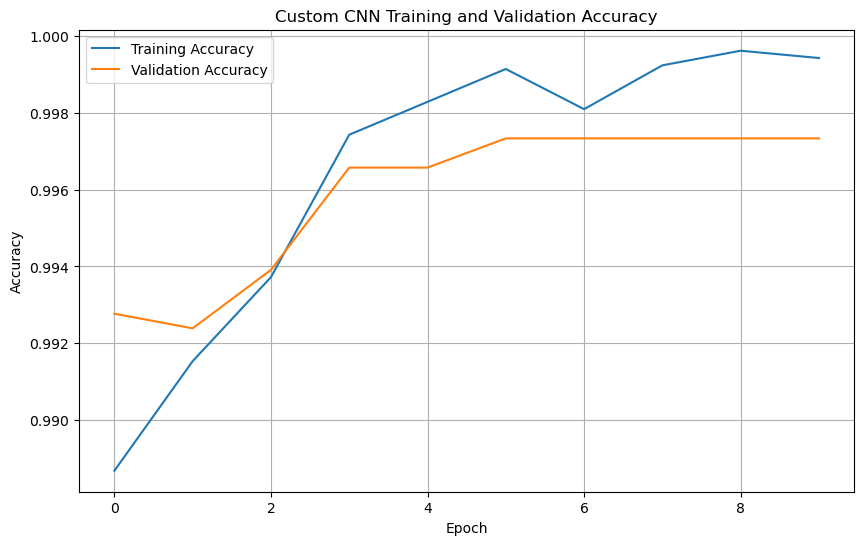

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

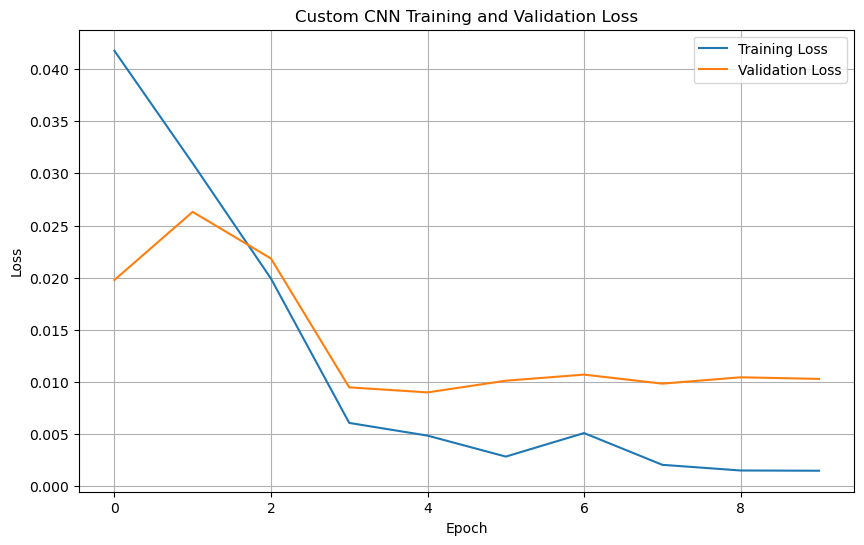

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Custom CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [55]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

Final Training Accuracy: 0.9994292855262756
Final Validation Accuracy: 0.9973363876342773
Final Training Loss: 0.0014728637179359794
Final Validation Loss: 0.010282490402460098
